In [7]:
from functions.cleaning_functions import convert_mmcif_to_pdb
from MDAnalysis.coordinates.memory import MemoryReader
from MDAnalysis.analysis import pca, align
from Bio.PDB import MMCIFParser, PDBIO
import MDAnalysis as mda
import pandas as pd
import numpy as np
import glob
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib 
import nglview as nv


# Used Full-ssequence

In [8]:
from sklearn.cluster import KMeans
def make_pca_plot_S(targetlist,SELEC,plot=False):
    # convert cifs to pdb
    for target in targetlist:
        convert_mmcif_to_pdb(target[:-3]+"cif")
    file_list = [target[:-3]+"pdb" for target in targetlist]

    # stack structures into single trajectory
    universe_list = [mda.Universe(path).select_atoms(SELEC) for  path in file_list]
    # Stack coordinates into a (2, n_atoms, 3) array
    coords = np.stack([item.atoms.positions.copy() for item in universe_list], axis=0)
    
    u = mda.Universe(file_list[0])
    u.trajectory = MemoryReader(coords)

    # run PCA

    pc = pca.PCA(u, select=SELEC,
                align=True, mean=None,
                n_components=10).run()

    backbone = u.select_atoms(SELEC)
   
    # visualize transformed structures in df

    transformed = pc.transform(backbone, n_components=3)
    df = pd.DataFrame(transformed,
                    columns=['PC{}'.format(i+1) for i in range(3)])
    df['Frame'] = df.index * u.trajectory.dt
    #df["name"]= [(path.split("seed")[-1].split("_")[1]) for path in targetlist]
    df["name"]= ['_'.join(path.split("fold_")[-1].split("_model")[0].split("_")[-2:]) for path in story]
    #df["name"] = ["np","np_X","np","np","np","np_c_X","np_c","np_c","np_c","np_c","p_c_X","p_c","p_c","p_c","p_c","p","p","p","p_X","p"]
    if plot:
        sns.scatterplot(df,x="PC1",y="PC2",hue='name')
        plt.legend(bbox_to_anchor=(1.4,1))


    return pc,u,df

# Full Sequence

In [9]:
story = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed1_noptms/*pdb")+glob.glob("cif_files/Predictions/TMTC3/*noptm_m*pdb")+glob.glob("cif_files/Predictions/TMTC3/*3_m*pdb")+glob.glob("cif_files/Predictions/SEEDMATCHED/*seed42_ptms/*pdb") 
pc,u,df = make_pca_plot_S(story,SELEC="chainID A")

Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_0.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_1.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_2.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_3.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_4.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_0.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_1.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_2.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_3.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_4.pdb
Saved PDB file 

C:\Users\maxvV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\MDAnalysis\analysis\pca.py:329: DeprecationWarning: The `variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


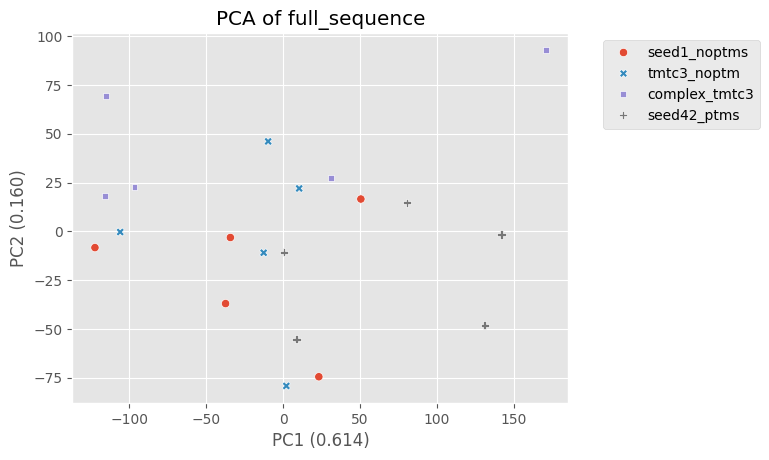

In [10]:
plt.style.use('ggplot')
plt.title("PCA of full_sequence")
sns.scatterplot(df,x="PC1",y="PC2",hue='name',style="name")
plt.xlabel(f"PC1 ({(pc.variance[0])/sum(pc.results.variance):.3f})")
plt.ylabel(f"PC2 ({(pc.variance[1])/sum(pc.results.variance):.3f})")
plt.legend(bbox_to_anchor=(1.4,1))

Cumulated variance 1: 0.602
Cumulated variance 2: 0.758
Cumulated variance 3: 0.858


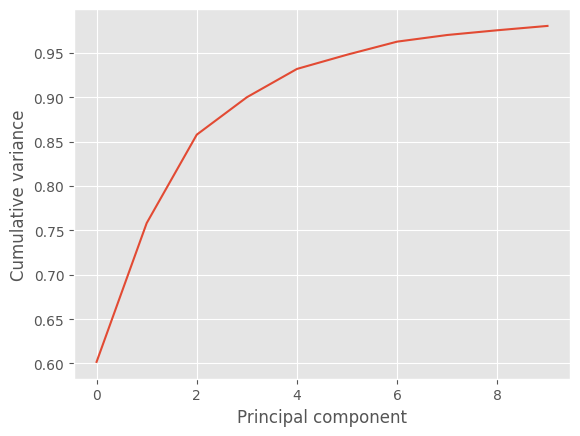

In [11]:
for i in range(3):
    print(f"Cumulated variance {i+1}: {pc.results.cumulated_variance[i]:.3f}")
plt.plot(pc.results.cumulated_variance[:10])
plt.xlabel('Principal component')
plt.ylabel('Cumulative variance')
plt.show()

In [12]:

backbone = u.select_atoms("chainID A")
transformed = pc.transform(backbone, n_components=3)

pc1 = pc.results.p_components[:, 0]
trans1 = transformed[:, 0]
projected = np.outer(trans1, pc1) + pc.mean.flatten()
coordinates = projected.reshape(len(trans1), -1, 3)
proj1 = mda.Merge(backbone)
proj1.load_new(coordinates, order="fac")
view = nv.show_mdanalysis(proj1.atoms)
view

NGLWidget(max_frame=19)

In [13]:
for i in range(3):
    cc = pca.cosine_content(transformed, i)
    print(f"Cosine content for PC {i+1} = {cc:.3f}")

Cosine content for PC 1 = 0.055
Cosine content for PC 2 = 0.151
Cosine content for PC 3 = 0.091


In [14]:
df3 = pd.DataFrame(transformed,
                  columns=['PC{}'.format(i+1) for i in range(3)])
df3['Frame'] = df.index * u.trajectory.dt
df3.head()

,PC1,PC2,PC3,Frame
0,-122.324734,-8.334128,24.552642,0
1,50.476087,16.550326,-49.288108,1
2,23.165313,-74.491083,0.562928,2
3,-34.319494,-3.162804,8.408390,3
4,-37.443437,-37.012610,-5.030266,4


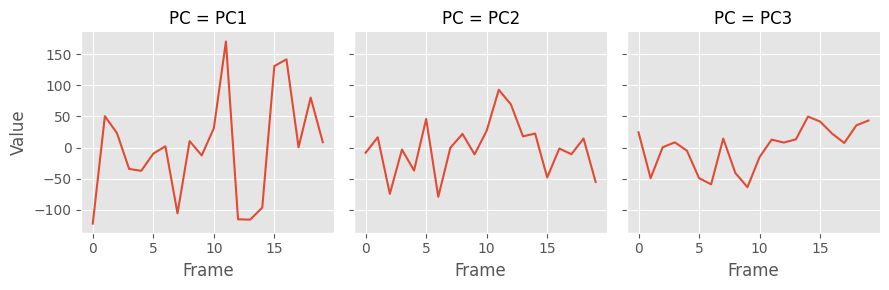

In [15]:
# melt the dataframe into a tidy format
melted = pd.melt(df3, id_vars=["Frame"],
                 var_name="PC",
                 value_name="Value")
g = sns.FacetGrid(melted, col="PC")
g.map(sns.lineplot,
      "Frame", # x-axis
      "Value") # no confidence interval
plt.show()

In [16]:
proj1.atoms.write("pcatraj/ALLstory_pc2.pdb")
with mda.Writer("pcatraj/ALLstory_pc2.dcd", proj1.atoms.n_atoms) as W:
    for ts in proj1.trajectory:
        W.write(proj1.atoms)

C:\Users\maxvV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\MDAnalysis\coordinates\PDB.py:777: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn("Unit cell dimensions not found. "
C:\Users\maxvV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\MDAnalysis\coordinates\PDB.py:1153: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"
C:\Users\maxvV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)


# Ec1-2 

In [17]:
paths1 = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed1_noptms/*cif")
patsh1n = glob.glob("cif_files/Predictions/notemplate/*seed1*/*cif")

paths2 = glob.glob("cif_files/Predictions/TMTC3/*noptm_m*pdb")
paths2n = glob.glob("cif_files/Predictions/notemplate/*tmtc3_nop*/*cif")

paths3 = glob.glob("cif_files/Predictions/TMTC3/*3_m*cif")
paths3n = glob.glob("cif_files/Predictions/notemplate/*tmtc3_not*/*cif")

paths4 = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed42_ptms/*cif")
paths4n = glob.glob("cif_files/Predictions/notemplate/*_ptm_*/*cif")
story = paths1+patsh1n+paths2+paths2n+paths3+paths3n+paths4+paths4n

In [18]:
story = glob.glob("cif_files/Predictions/SEEDMATCHED/*seed1_noptms/*pdb")+glob.glob("cif_files/Predictions/TMTC3/*noptm_m*pdb")+glob.glob("cif_files/Predictions/TMTC3/*3_m*pdb")+glob.glob("cif_files/Predictions/SEEDMATCHED/*seed42_ptms/*pdb") 
pc2,u2,df2 = make_pca_plot_S(story,SELEC="index 0:1700")

Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_0.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_1.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_2.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_3.pdb
Saved PDB file to: cif_files/Predictions/SEEDMATCHED\fold_adnan_seed1_noptms\fold_adnan_seed1_noptms_model_4.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_0.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_1.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_2.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_3.pdb
Saved PDB file to: cif_files/Predictions/TMTC3\fold_complex_tmtc3_noptm_model_4.pdb
Saved PDB file 

C:\Users\maxvV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\MDAnalysis\analysis\pca.py:329: DeprecationWarning: The `variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


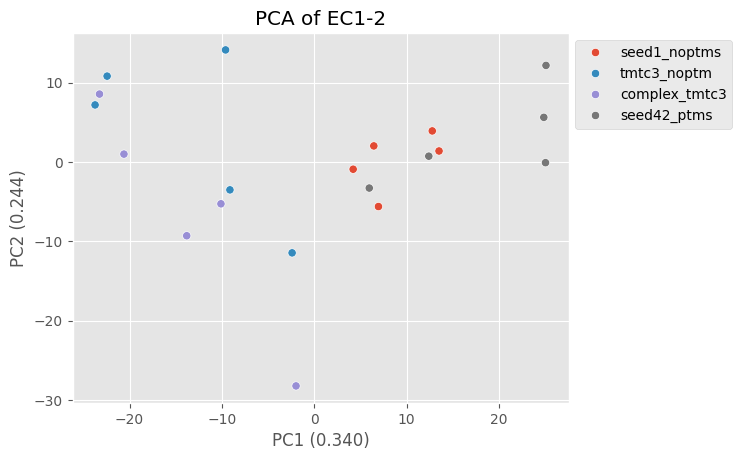

In [19]:
plt.style.use('ggplot')
#df2["names"] = np.repeat(["noptm","noptm_bnd","ptm_bnd","ptm"],10)
plt.title("PCA of EC1-2")
sns.scatterplot(df2,x="PC1",y="PC3",hue="name")
plt.xlabel(f"PC1 ({(pc2.variance[0])/sum(pc2.results.variance):.3f})")
plt.ylabel(f"PC2 ({(pc2.variance[1])/sum(pc2.results.variance):.3f})")
plt.legend(bbox_to_anchor=(1,1))


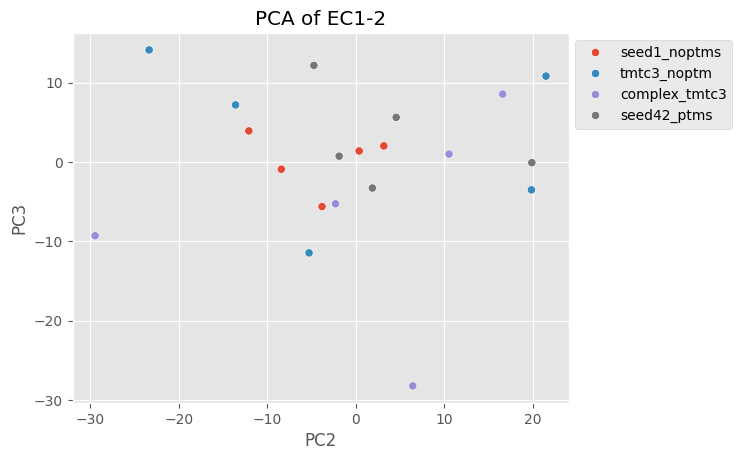

In [20]:
plt.title("PCA of EC1-2")
sns.scatterplot(df2,x="PC2",y="PC3",hue="name")
plt.legend(bbox_to_anchor=(1,1))

Cumulated variance 1: 0.320
Cumulated variance 2: 0.550
Cumulated variance 3: 0.661
Cumulated variance 4: 0.762


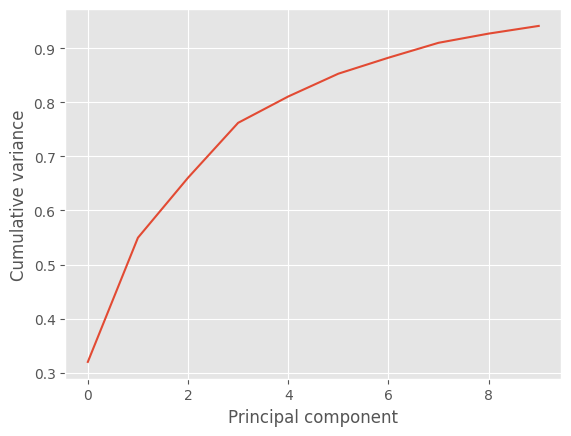

In [21]:
for i in range(4):
    print(f"Cumulated variance {i+1}: {pc2.results.cumulated_variance[i]:.3f}")
plt.plot(pc2.results.cumulated_variance[:10])
plt.xlabel('Principal component')
plt.ylabel('Cumulative variance')
plt.show()

In [22]:
from numpy import array

# Import dependencies for 3d plotting
import plotly
import plotly.graph_objs as go

In [25]:
data = []
for name in df2["name"].unique():
    x,y,z = df2[df2["name"]==name]["PC1"],df2[df2["name"]==name]["PC2"],df2[df2["name"]==name]["PC3"]
    trace = go.Scatter3d(x=x,y=y,z=z,mode='markers',
                            marker={'size': 5},name=name)
    
    data.append(trace)
layout = go.Layout(margin={'l': 0, 'r': 0, 'b': 0, 't': 0})

plot_figure = go.Figure(data=data, layout=layout)
plot_figure.layout.scene.camera.projection.type = "orthographic"
plot_figure.show(renderer="browser")  # remove display(fig)
plotly.offline.iplot(plot_figure)

In [ ]:
view = nv.show_mdanalysis(proj2.atoms)
view

NGLWidget(max_frame=19)